<a href="https://colab.research.google.com/github/Anjanachenchani/Anjana/blob/main/smart_office_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Office Space Design & Optimization

This project models an office layout using the ten mathematical topics required in the project brief:

1. Algebra
2. Exponentials & Logarithms
3. Functions & Graphs
4. Derivatives
5. Integration
6. Calculus / Optimization
7. Linear Algebra
8. Probability
9. Graph Theory
10. Multivariable Calculus

All calculations and visualizations are generated by Python code. The assumptions are kept in one place so that parameters can be changed easily during the viva.

## 0. Imports and Assumptions

The office contains Reception, Manager Cabin, Workstations, Conference Room, Pantry, Storage, and Washrooms.

The numerical assumptions below are project-model assumptions and can be changed without changing the mathematical structure of the notebook.

In [3]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import quad
from scipy.optimize import minimize

np.random.seed(42)

# ----------------------------
# Global project assumptions
# ----------------------------
EMPLOYEES = 30
FLOORING_COST_SQFT = 45.0
ELECTRICAL_COST_SQFT = 25.0
FURNITURE_COST_EMPLOYEE = 1200.0
ANNUAL_INFLATION = 0.06
YEARS = 5
BUDGET_CAP = 310446.0

# Usage probabilities for each office space
USAGE_PROBABILITIES = {
    "Reception": 0.90,
    "Manager Cabin": 0.70,
    "Workstations": 0.85,
    "Conference Room": 0.40,
    "Pantry": 0.60,
    "Storage": 0.20,
    "Washrooms": 0.75,
}

# Baseline room dimensions in feet: width x depth
BASELINE_ROOMS = {
    "Reception": (15, 12),
    "Manager Cabin": (14, 12),
    "Workstations": (40, 18),
    "Conference Room": (25, 18),
    "Pantry": (15, 10),
    "Storage": (10, 10),
    "Washrooms": (15, 12),
}

print("Project assumptions loaded successfully.")
print(f"Employees: {EMPLOYEES}")
print(f"Flooring cost: ${FLOORING_COST_SQFT:.2f}/sq ft")
print(f"Electrical cost: ${ELECTRICAL_COST_SQFT:.2f}/sq ft")
print(f"Furniture cost per employee: ${FURNITURE_COST_EMPLOYEE:.2f}")
print(f"Annual inflation: {ANNUAL_INFLATION:.0%}")

Project assumptions loaded successfully.
Employees: 30
Flooring cost: $45.00/sq ft
Electrical cost: $25.00/sq ft
Furniture cost per employee: $1200.00
Annual inflation: 6%


## Module 1 — Algebra: Space and Cost Calculations

We calculate room areas, total office area, furniture area, remaining usable/free space, flooring cost, electrical cost, furniture cost, and total base cost.

In [4]:
def room_area(width, depth):
    return width * depth

def calculate_algebra_model(rooms, employees=EMPLOYEES):
    room_areas = {name: room_area(w, d) for name, (w, d) in rooms.items()}
    total_area = sum(room_areas.values())
    # Approximate furniture footprint: 40 sq ft per employee
    furniture_area = employees * 40.0
    remaining_free_space = total_area - furniture_area
    flooring_cost = total_area * FLOORING_COST_SQFT
    electrical_cost = total_area * ELECTRICAL_COST_SQFT
    furniture_cost = employees * FURNITURE_COST_EMPLOYEE
    base_total_cost = flooring_cost + electrical_cost + furniture_cost
    return {
        "room_areas": room_areas,
        "total_area": total_area,
        "furniture_area": furniture_area,
        "remaining_free_space": remaining_free_space,
        "flooring_cost": flooring_cost,
        "electrical_cost": electrical_cost,
        "furniture_cost": furniture_cost,
        "base_total_cost": base_total_cost,
    }

algebra = calculate_algebra_model(BASELINE_ROOMS)

print("--- MODULE 1: ALGEBRA OUTPUT ---")
for room, area in algebra["room_areas"].items():
    print(f"{room:18s}: {area:7.1f} sq ft")
print(f"Total Office Area:         {algebra['total_area']:.1f} sq ft")
print(f"Furniture Footprint:       {algebra['furniture_area']:.1f} sq ft")
print(f"Remaining Free Space:      {algebra['remaining_free_space']:.1f} sq ft")
print(f"Flooring Cost:             ${algebra['flooring_cost']:,.2f}")
print(f"Electrical Cost:           ${algebra['electrical_cost']:,.2f}")
print(f"Furniture Cost:            ${algebra['furniture_cost']:,.2f}")
print(f"Base Total Cost:           ${algebra['base_total_cost']:,.2f}")

--- MODULE 1: ALGEBRA OUTPUT ---
Reception         :   180.0 sq ft
Manager Cabin     :   168.0 sq ft
Workstations      :   720.0 sq ft
Conference Room   :   450.0 sq ft
Pantry            :   150.0 sq ft
Storage           :   100.0 sq ft
Washrooms         :   180.0 sq ft
Total Office Area:         1948.0 sq ft
Furniture Footprint:       1200.0 sq ft
Remaining Free Space:      748.0 sq ft
Flooring Cost:             $87,660.00
Electrical Cost:           $48,700.00
Furniture Cost:            $36,000.00
Base Total Cost:           $172,360.00


## Module 1 — Generated 2D Office Floor Plan

The layout below is generated entirely by code. Unlike the earlier version, rooms do not overlap: the workstation area is placed separately from Reception and the Manager Cabin.

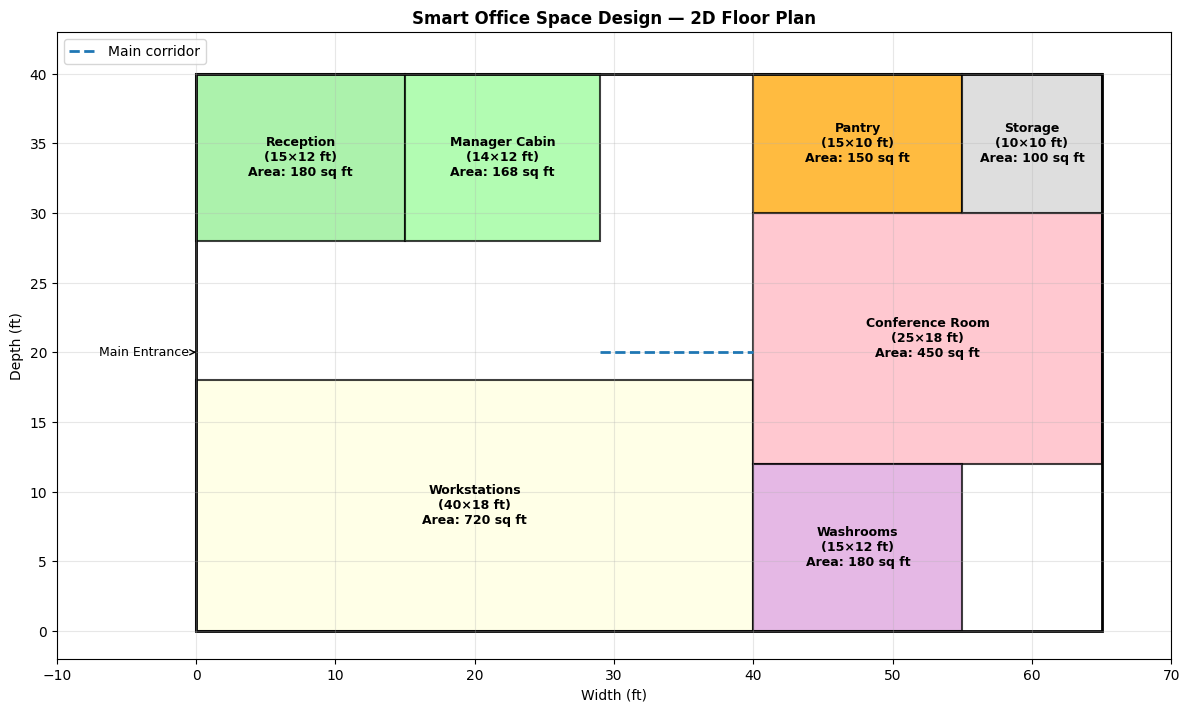

In [5]:
# A non-overlapping baseline floor plan.
# Coordinates are (x, y) = lower-left corner.
LAYOUT = {
    "Reception":       (0, 28, 15, 12),
    "Manager Cabin":   (15, 28, 14, 12),
    "Workstations":    (0, 0, 40, 18),
    "Conference Room": (40, 12, 25, 18),
    "Pantry":          (40, 30, 15, 10),
    "Storage":         (55, 30, 10, 10),
    "Washrooms":       (40, 0, 15, 12),
}

ROOM_FILL = {
    "Reception": "lightgreen",
    "Manager Cabin": "palegreen",
    "Workstations": "lightyellow",
    "Conference Room": "lightpink",
    "Pantry": "orange",
    "Storage": "lightgray",
    "Washrooms": "plum",
}

def draw_floor_plan(layout, title="Smart Office Space Design — 2D Floor Plan"):
    fig, ax = plt.subplots(figsize=(12, 8))
    for room, (x, y, w, h) in layout.items():
        rect = plt.Rectangle(
            (x, y), w, h,
            facecolor=ROOM_FILL[room],
            edgecolor="black",
            linewidth=1.5,
            alpha=0.75
        )
        ax.add_patch(rect)
        ax.text(
            x + w/2, y + h/2,
            f"{room}\n({w}×{h} ft)\nArea: {w*h:.0f} sq ft",
            ha="center", va="center", fontsize=9, fontweight="bold"
        )
    # Building boundary
    ax.add_patch(plt.Rectangle((0, 0), 65, 40, fill=False, edgecolor="black", linewidth=2))
    # Main entrance and corridor indication
    ax.annotate("Main Entrance", xy=(0, 20), xytext=(-7, 20),
                arrowprops=dict(arrowstyle="->"), va="center", fontsize=9)
    ax.plot([29, 40], [20, 20], linestyle="--", linewidth=2, label="Main corridor")
    ax.set_xlim(-10, 70)
    ax.set_ylim(-2, 43)
    ax.set_aspect("equal")
    ax.set_xlabel("Width (ft)")
    ax.set_ylabel("Depth (ft)")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

draw_floor_plan(LAYOUT)

## Module 2 — Exponentials & Logarithms: Future Costs

The cost model uses exponential growth:

[ C(t)=C_0(1+r)^t ]

To find the time at which a budget is reached, logarithms are used:

[ t = \frac{\ln(B/C_0)}{\ln(1+r)} ]

--- MODULE 2: EXPONENTIALS & LOGARITHMS OUTPUT ---
Base Cost: $172,360.00
Annual Inflation Rate: 6.0%
Projected Cost After 5 Years: $230,656.56
Budget Cap: $310,446.00
Logarithmic Time to Reach Budget: 10.10 years


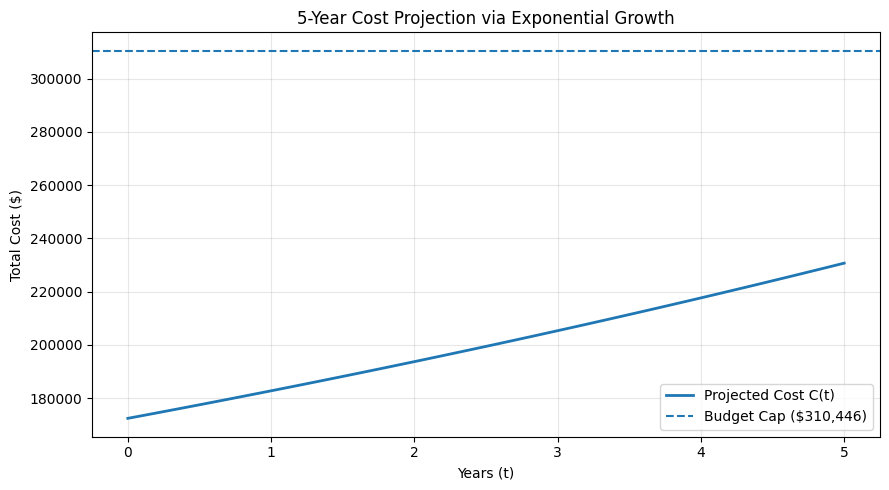

In [6]:
def future_cost(base_cost, rate, years):
    return base_cost * (1 + rate) ** years

base_cost = algebra["base_total_cost"]
t_values = np.linspace(0, YEARS, 101)
projected_costs = future_cost(base_cost, ANNUAL_INFLATION, t_values)

# Explicit logarithmic calculation
if BUDGET_CAP > base_cost:
    breach_time = math.log(BUDGET_CAP / base_cost) / math.log(1 + ANNUAL_INFLATION)
else:
    breach_time = 0.0

print("--- MODULE 2: EXPONENTIALS & LOGARITHMS OUTPUT ---")
print(f"Base Cost: ${base_cost:,.2f}")
print(f"Annual Inflation Rate: {ANNUAL_INFLATION:.1%}")
print(f"Projected Cost After {YEARS} Years: ${future_cost(base_cost, ANNUAL_INFLATION, YEARS):,.2f}")
print(f"Budget Cap: ${BUDGET_CAP:,.2f}")
print(f"Logarithmic Time to Reach Budget: {breach_time:.2f} years")

plt.figure(figsize=(9, 5))
plt.plot(t_values, projected_costs, label="Projected Cost C(t)", linewidth=2)
plt.axhline(BUDGET_CAP, linestyle="--", label=f"Budget Cap (${BUDGET_CAP:,.0f})")
if breach_time <= YEARS:
    plt.axvline(breach_time, linestyle=":", label=f"Budget Time ({breach_time:.2f} yrs)")
plt.xlabel("Years (t)")
plt.ylabel("Total Cost ($)")
plt.title("5-Year Cost Projection via Exponential Growth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Module 3 — Functions & Graphs

Three relationships are modeled:

* Employees vs required space
* Employees vs furniture cost
* Office area vs total cost

These functions allow the effect of changing employee count and office size to be visualized.

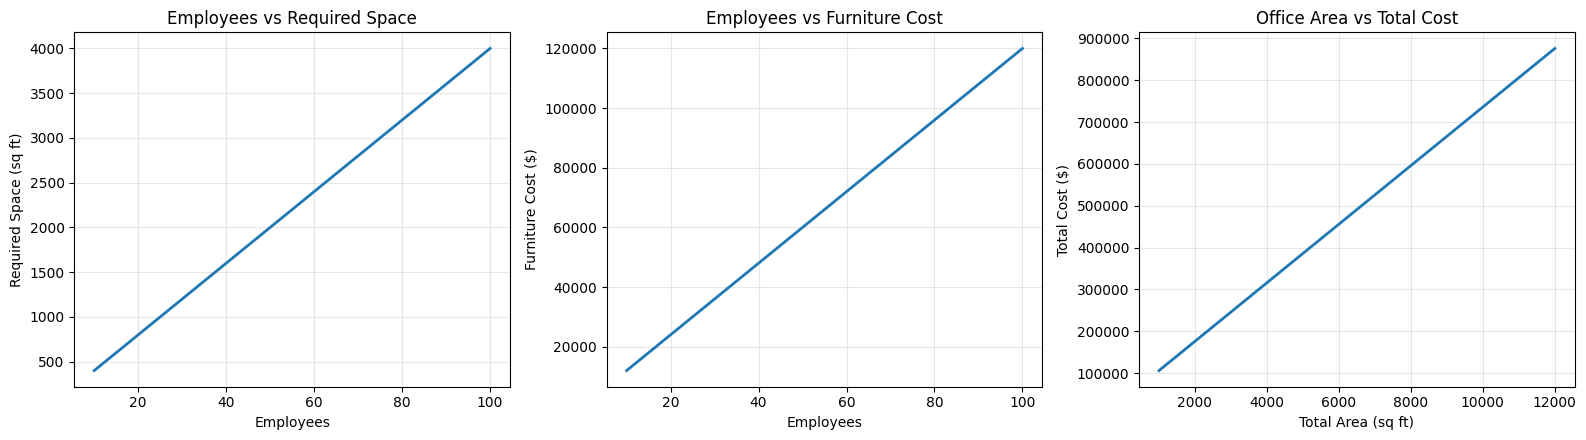

--- MODULE 3: FUNCTIONS & GRAPHS OUTPUT ---
Space required for 30 employees: 1200.0 sq ft
Furniture cost for 30 employees: $36,000.00


In [7]:
def required_space(employees, space_per_employee=40.0):
    return employees * space_per_employee

def furniture_cost(employees):
    return employees * FURNITURE_COST_EMPLOYEE

def total_cost_from_area(area, employees=EMPLOYEES):
    return (
        area * FLOORING_COST_SQFT
        + area * ELECTRICAL_COST_SQFT
        + furniture_cost(employees)
    )

employees_values = np.arange(10, 101, 5)
required_space_values = required_space(employees_values)
furniture_cost_values = furniture_cost(employees_values)
area_values = np.linspace(1000, 12000, 100)
total_cost_values = total_cost_from_area(area_values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(employees_values, required_space_values, linewidth=2)
axes[0].set_title("Employees vs Required Space")
axes[0].set_xlabel("Employees")
axes[0].set_ylabel("Required Space (sq ft)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(employees_values, furniture_cost_values, linewidth=2)
axes[1].set_title("Employees vs Furniture Cost")
axes[1].set_xlabel("Employees")
axes[1].set_ylabel("Furniture Cost ($)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(area_values, total_cost_values, linewidth=2)
axes[2].set_title("Office Area vs Total Cost")
axes[2].set_xlabel("Total Area (sq ft)")
axes[2].set_ylabel("Total Cost ($)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- MODULE 3: FUNCTIONS & GRAPHS OUTPUT ---")
print(f"Space required for {EMPLOYEES} employees: {required_space(EMPLOYEES):.1f} sq ft")
print(f"Furniture cost for {EMPLOYEES} employees: ${furniture_cost(EMPLOYEES):,.2f}")

## Module 4 — Derivatives: Rates of Change

For the cost function

[ C(A)=F+(p_f+p_e)A ]

the derivative (dC/dA) is the marginal cost of one additional square foot.

--- MODULE 4: DERIVATIVES OUTPUT ---
Symbolic Cost Function: C(A) = 70.0*A + 36000.0
Marginal Cost dC/dA = 70.0000000000000


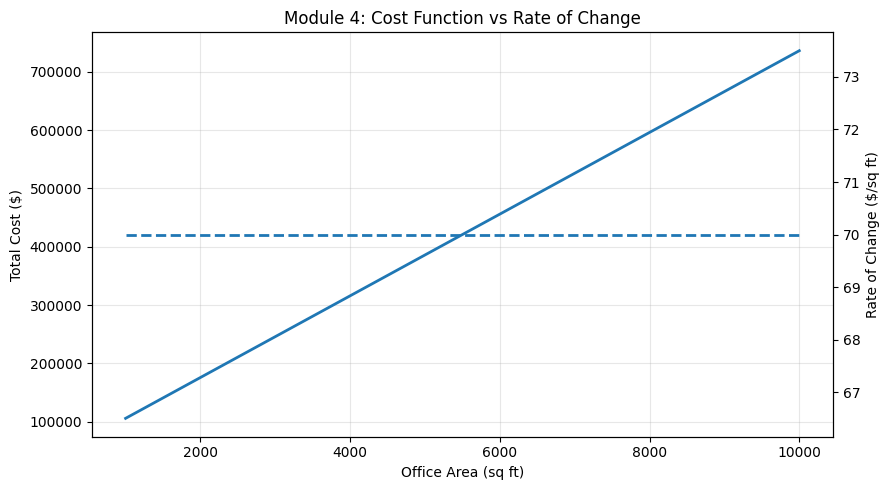

In [8]:
A = sp.symbols("A", positive=True)
fixed_cost = EMPLOYEES * FURNITURE_COST_EMPLOYEE
cost_per_sqft = FLOORING_COST_SQFT + ELECTRICAL_COST_SQFT
C_expr = fixed_cost + cost_per_sqft * A
dC_dA = sp.diff(C_expr, A)

print("--- MODULE 4: DERIVATIVES OUTPUT ---")
print(f"Symbolic Cost Function: C(A) = {sp.expand(C_expr)}")
print(f"Marginal Cost dC/dA = {dC_dA}")

A_values = np.linspace(1000, 10000, 100)
C_values = fixed_cost + cost_per_sqft * A_values
derivative_values = np.full_like(A_values, float(dC_dA))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(A_values, C_values, linewidth=2, label="Total Cost C(A)")
ax1.set_xlabel("Office Area (sq ft)")
ax1.set_ylabel("Total Cost ($)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(A_values, derivative_values, linestyle="--", linewidth=2, label="dC/dA")
ax2.set_ylabel("Rate of Change ($/sq ft)")
ax1.set_title("Module 4: Cost Function vs Rate of Change")
fig.tight_layout()
plt.show()

## Module 5 — Integration: Curved Reception

To make the integration example consistent with the design, the reception includes a semicircular curved feature.

For a semicircle of radius (r), the area can be found using integration:

[ A=\int_{-r}^{r}\sqrt{r^2-x^2},dx ]

This equals (\pi r^2/2), and the numerical integral is compared with the exact result.

--- MODULE 5: INTEGRATION OUTPUT ---
Semicircle Radius: 5.0 ft
Integrated Area: 39.2699 sq ft
Exact Area (πr²/2): 39.2699 sq ft
Absolute Error: 0.00000000 sq ft


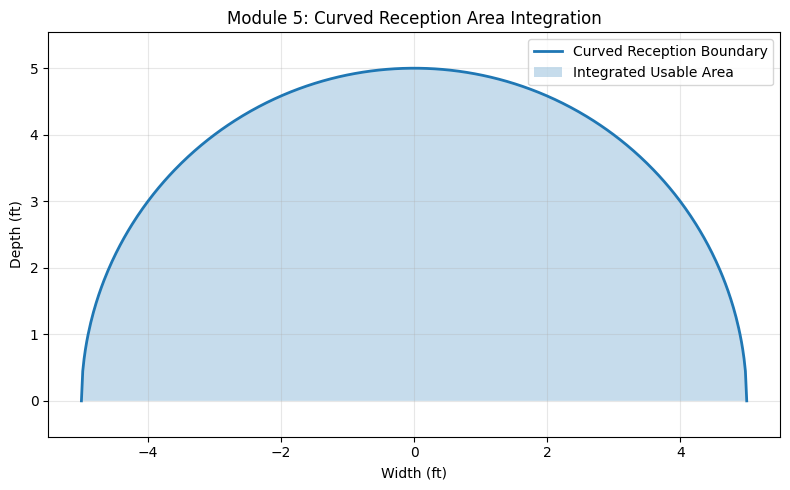

In [9]:
radius = 5.0

def upper_semicircle(x):
    return math.sqrt(max(radius**2 - x**2, 0))

integrated_area, integration_error = quad(upper_semicircle, -radius, radius)
exact_area = 0.5 * math.pi * radius**2

print("--- MODULE 5: INTEGRATION OUTPUT ---")
print(f"Semicircle Radius: {radius:.1f} ft")
print(f"Integrated Area: {integrated_area:.4f} sq ft")
print(f"Exact Area (πr²/2): {exact_area:.4f} sq ft")
print(f"Absolute Error: {abs(integrated_area - exact_area):.8f} sq ft")

x = np.linspace(-radius, radius, 500)
y = np.sqrt(np.maximum(radius**2 - x**2, 0))

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2, label="Curved Reception Boundary")
plt.fill_between(x, y, 0, alpha=0.25, label="Integrated Usable Area")
plt.xlabel("Width (ft)")
plt.ylabel("Depth (ft)")
plt.title("Module 5: Curved Reception Area Integration")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Module 6 — Calculus / Optimization: Best Design

The optimization minimizes a combined objective:

[ J = \text{Cost} + \lambda_d(\text{Walking Distance}) +\lambda_s(\text{Space Penalty}) +\lambda_c(\text{Conference Penalty}) ]

The decision variables are:

* workstation space per employee
* conference-room area

The optimizer searches within realistic bounds and the resulting parameters are used to generate a second, optimized floor plan.

--- MODULE 6: OPTIMIZATION ENGINE OUTPUT ---
Optimization success: True
Baseline Area per Employee: 40.00 sq ft
Optimized Area per Employee: 30.00 sq ft
Baseline Conference Area: 450.00 sq ft
Optimized Conference Area: 300.00 sq ft
Baseline Walking Distance Metric: 57.00 ft
Optimized Objective Score: 287.56
Baseline Objective Score: 319.96
Baseline Total Cost:  $172,360.00
Optimized Total Cost: $174,460.00


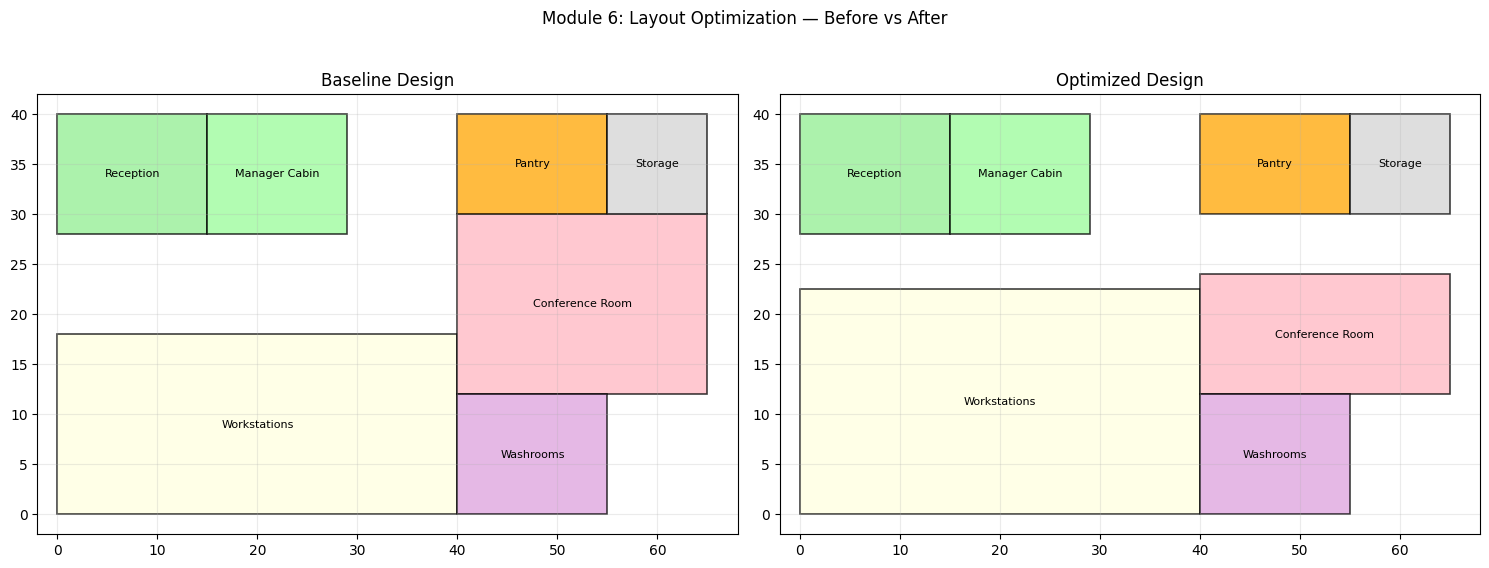

In [10]:
# Weighted walking network used by the optimization model.
BASE_EDGES = [
    ("Reception", "Manager Cabin", 8),
    ("Reception", "Workstations", 12),
    ("Manager Cabin", "Conference Room", 10),
    ("Workstations", "Conference Room", 10),
    ("Workstations", "Pantry", 15),
    ("Workstations", "Washrooms", 14),
    ("Workstations", "Storage", 6),
    ("Pantry", "Washrooms", 4),
]

G_base = nx.Graph()
G_base.add_weighted_edges_from(BASE_EDGES)

baseline_space_per_employee = 40.0
baseline_conference_area = BASELINE_ROOMS["Conference Room"][0] * BASELINE_ROOMS["Conference Room"][1]

def shortest_path_total(graph):
    pairs = [
        ("Reception", "Workstations"),
        ("Workstations", "Conference Room"),
        ("Workstations", "Pantry"),
        ("Workstations", "Washrooms"),
        ("Workstations", "Storage"),
    ]
    return sum(nx.shortest_path_length(graph, a, b, weight="weight") for a, b in pairs)

baseline_walk = shortest_path_total(G_base)

def optimization_objective(x):
    space_per_emp, conference_area = x
    total_area = (
        algebra["total_area"]
        - algebra["room_areas"]["Workstations"]
        - algebra["room_areas"]["Conference Room"]
        + space_per_emp * EMPLOYEES
        + conference_area
    )
    total_cost = total_cost_from_area(total_area, EMPLOYEES)

    space_penalty = max(0, 30 - space_per_emp) ** 2 * 1000
    conference_penalty = max(0, 300 - conference_area) ** 2 * 5
    walking_distance = baseline_walk + 0.03 * (conference_area - baseline_conference_area) / 10

    return (
        total_cost / 1000
        + 2.0 * walking_distance
        + space_penalty
        + conference_penalty
    )

result = minimize(
    optimization_objective,
    x0=np.array([baseline_space_per_employee, baseline_conference_area]),
    bounds=[(30, 80), (300, 600)],
    method="L-BFGS-B"
)

optimized_space_per_employee, optimized_conference_area = result.x
baseline_objective = optimization_objective([baseline_space_per_employee, baseline_conference_area])
optimized_objective = result.fun

print("--- MODULE 6: OPTIMIZATION ENGINE OUTPUT ---")
print(f"Optimization success: {result.success}")
print(f"Baseline Area per Employee: {baseline_space_per_employee:.2f} sq ft")
print(f"Optimized Area per Employee: {optimized_space_per_employee:.2f} sq ft")
print(f"Baseline Conference Area: {baseline_conference_area:.2f} sq ft")
print(f"Optimized Conference Area: {optimized_conference_area:.2f} sq ft")
print(f"Baseline Walking Distance Metric: {baseline_walk:.2f} ft")
print(f"Optimized Objective Score: {optimized_objective:.2f}")
print(f"Baseline Objective Score: {baseline_objective:.2f}")

optimized_workstation_area = optimized_space_per_employee * EMPLOYEES
optimized_ws_width = 40.0
optimized_ws_depth = optimized_workstation_area / optimized_ws_width
optimized_conf_width = 25.0
optimized_conf_depth = optimized_conference_area / optimized_conf_width

OPTIMIZED_LAYOUT = {
    "Reception": (0, 28, 15, 12),
    "Manager Cabin": (15, 28, 14, 12),
    "Workstations": (0, 0, optimized_ws_width, optimized_ws_depth),
    "Conference Room": (40, 12, optimized_conf_width, optimized_conf_depth),
    "Pantry": (40, 30, 15, 10),
    "Storage": (55, 30, 10, 10),
    "Washrooms": (40, 0, 15, 12),
}

baseline_cost = algebra["base_total_cost"]
optimized_model = calculate_algebra_model(
    {k: (v[2], v[3]) for k, v in OPTIMIZED_LAYOUT.items()},
    EMPLOYEES
)
optimized_cost = optimized_model["base_total_cost"]

print(f"Baseline Total Cost:  ${baseline_cost:,.2f}")
print(f"Optimized Total Cost: ${optimized_cost:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, layout, title in [
    (axes[0], LAYOUT, "Baseline Design"),
    (axes[1], OPTIMIZED_LAYOUT, "Optimized Design")
]:
    for room, (x, y, w, h) in layout.items():
        ax.add_patch(plt.Rectangle(
            (x, y), w, h,
            facecolor=ROOM_FILL[room],
            edgecolor="black",
            linewidth=1.2,
            alpha=0.75
        ))
        ax.text(x+w/2, y+h/2, room, ha="center", va="center", fontsize=8)
    ax.set_xlim(-2, 68)
    ax.set_ylim(-2, 42)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

plt.suptitle("Module 6: Layout Optimization — Before vs After")
plt.tight_layout()
plt.show()

## Module 7 — Linear Algebra: Furniture Positioning and Transformation

Furniture is represented by coordinate vectors. Homogeneous transformation matrices are used to rotate and translate furniture, similar to a simplified CAD operation.

--- MODULE 7: LINEAR ALGEBRA OUTPUT ---
Desk A             transformed centroid: (11.09, 12.87)
Sofa               transformed centroid: (28.28, 17.48)
Conference Table   transformed centroid: (44.07, 35.06)


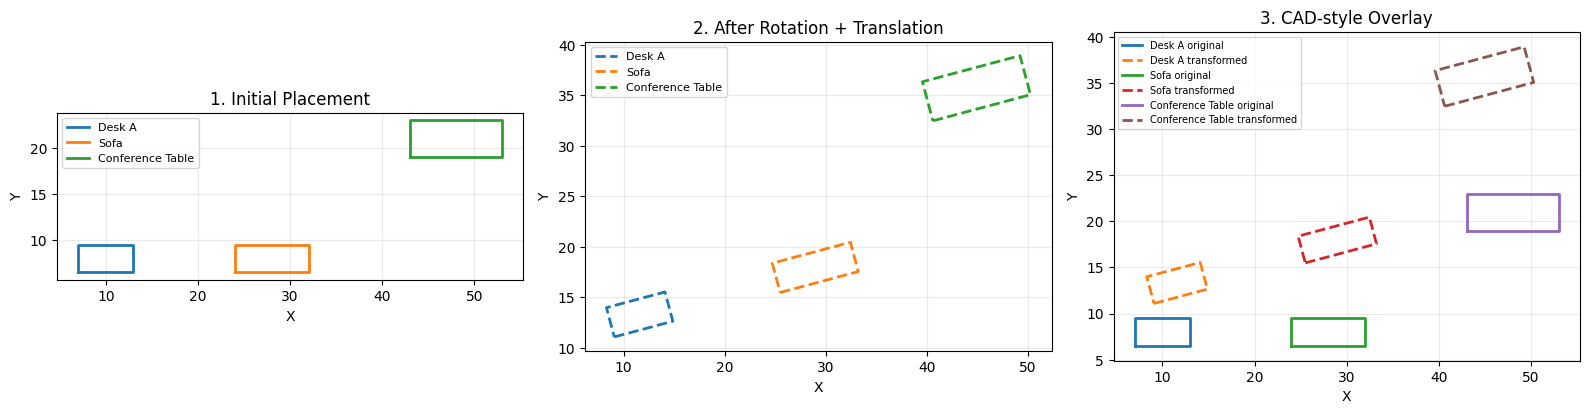

In [11]:
def rectangle_corners(cx, cy, width, height):
    return np.array([
        [cx - width/2, cy - height/2, 1],
        [cx + width/2, cy - height/2, 1],
        [cx + width/2, cy + height/2, 1],
        [cx - width/2, cy + height/2, 1],
        [cx - width/2, cy - height/2, 1],
    ]).T

furniture = {
    "Desk A": rectangle_corners(10, 8, 6, 3),
    "Sofa": rectangle_corners(28, 8, 8, 3),
    "Conference Table": rectangle_corners(48, 21, 10, 4),
}

theta = math.radians(15)
rotation = np.array([
    [math.cos(theta), -math.sin(theta), 0],
    [math.sin(theta),  math.cos(theta), 0],
    [0, 0, 1]
])

translation = np.array([
    [1, 0, 4],
    [0, 1, 3],
    [0, 0, 1]
])

transform = translation @ rotation

transformed_furniture = {
    name: transform @ coords
    for name, coords in furniture.items()
}

print("--- MODULE 7: LINEAR ALGEBRA OUTPUT ---")
for name, coords in transformed_furniture.items():
    centroid = coords[:2].mean(axis=1)
    print(f"{name:18s} transformed centroid: ({centroid[0]:.2f}, {centroid[1]:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_furniture(ax, items, title, linestyle="-"):
    for name, coords in items.items():
        ax.plot(coords[0], coords[1], linestyle=linestyle, linewidth=2, label=name)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

plot_furniture(axes[0], furniture, "1. Initial Placement")
plot_furniture(axes[1], transformed_furniture, "2. After Rotation + Translation", "--")

for name in furniture:
    axes[2].plot(furniture[name][0], furniture[name][1], linewidth=2, label=f"{name} original")
    axes[2].plot(transformed_furniture[name][0], transformed_furniture[name][1],
                 linestyle="--", linewidth=2, label=f"{name} transformed")

axes[2].set_title("3. CAD-style Overlay")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")
axes[2].grid(True, alpha=0.25)
axes[2].set_aspect("equal")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Module 8 — Probability: Office Usage Simulation

Each room is assigned a probability of being used. Bernoulli simulation is performed over 250 working days.

The conference room is explicitly modeled with a 40% occupancy probability, matching the type of example described in the brief.

--- MODULE 8: PROBABILITY OUTPUT ---
Reception         : theoretical=0.90, simulated=0.896, occupied days=224/250
Manager Cabin     : theoretical=0.70, simulated=0.684, occupied days=171/250
Workstations      : theoretical=0.85, simulated=0.856, occupied days=214/250
Conference Room   : theoretical=0.40, simulated=0.356, occupied days=89/250
Pantry            : theoretical=0.60, simulated=0.508, occupied days=127/250
Storage           : theoretical=0.20, simulated=0.192, occupied days=48/250
Washrooms         : theoretical=0.75, simulated=0.764, occupied days=191/250


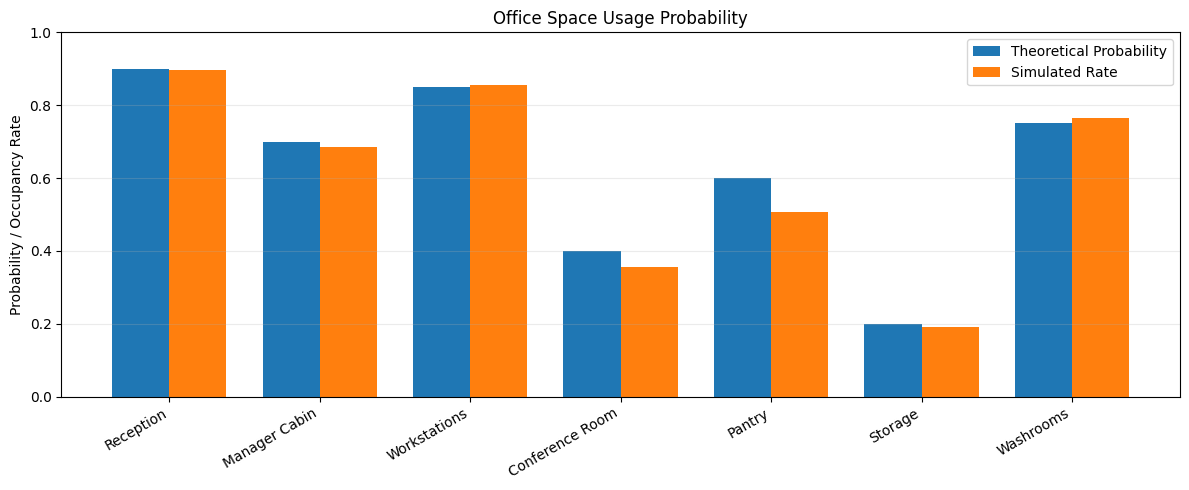

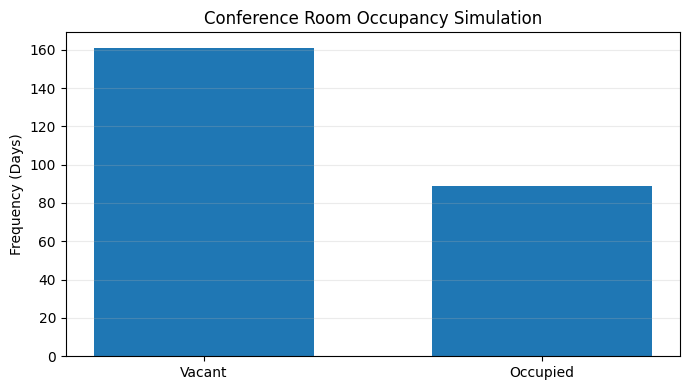

In [12]:
DAYS = 250
usage_results = {}

for room, probability in USAGE_PROBABILITIES.items():
    simulations = np.random.binomial(1, probability, DAYS)
    usage_results[room] = {
        "probability": probability,
        "occupied_days": int(simulations.sum()),
        "empirical_rate": float(simulations.mean()),
        "simulation": simulations,
    }

print("--- MODULE 8: PROBABILITY OUTPUT ---")
for room, data in usage_results.items():
    print(
        f"{room:18s}: theoretical={data['probability']:.2f}, "
        f"simulated={data['empirical_rate']:.3f}, "
        f"occupied days={data['occupied_days']}/{DAYS}"
    )

rooms = list(USAGE_PROBABILITIES.keys())
theoretical = [USAGE_PROBABILITIES[r] for r in rooms]
empirical = [usage_results[r]["empirical_rate"] for r in rooms]
x = np.arange(len(rooms))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, theoretical, width, label="Theoretical Probability")
plt.bar(x + width/2, empirical, width, label="Simulated Rate")
plt.xticks(x, rooms, rotation=30, ha="right")
plt.ylabel("Probability / Occupancy Rate")
plt.title("Office Space Usage Probability")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Dedicated conference-room simulation distribution
conference_sim = usage_results["Conference Room"]["simulation"]
plt.figure(figsize=(7, 4))
plt.hist(conference_sim, bins=[-0.5, 0.5, 1.5], rwidth=0.65)
plt.xticks([0, 1], ["Vacant", "Occupied"])
plt.ylabel("Frequency (Days)")
plt.title("Conference Room Occupancy Simulation")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Module 9 — Graph Theory: Walking Paths

Rooms are graph nodes and walking paths are weighted edges. NetworkX is used to calculate shortest paths and degree centrality.

Degree centrality is used as a simple indicator of which room is the most connected traffic hub.

--- MODULE 9: GRAPH THEORY OUTPUT ---
Reception → Pantry
  Shortest Path: Reception → Workstations → Pantry
  Distance: 27.0 ft
Reception → Storage
  Shortest Path: Reception → Workstations → Storage
  Distance: 18.0 ft
Manager Cabin → Washrooms
  Shortest Path: Manager Cabin → Reception → Workstations → Washrooms
  Distance: 34.0 ft

Degree Centrality (Traffic Hub Indicator):
  Reception         : 0.33
  Manager Cabin     : 0.33
  Workstations      : 0.83
  Conference Room   : 0.33
  Pantry            : 0.33
  Storage           : 0.17
  Washrooms         : 0.33

Most connected traffic hub: Workstations


/tmp/ipykernel_540/3659825681.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


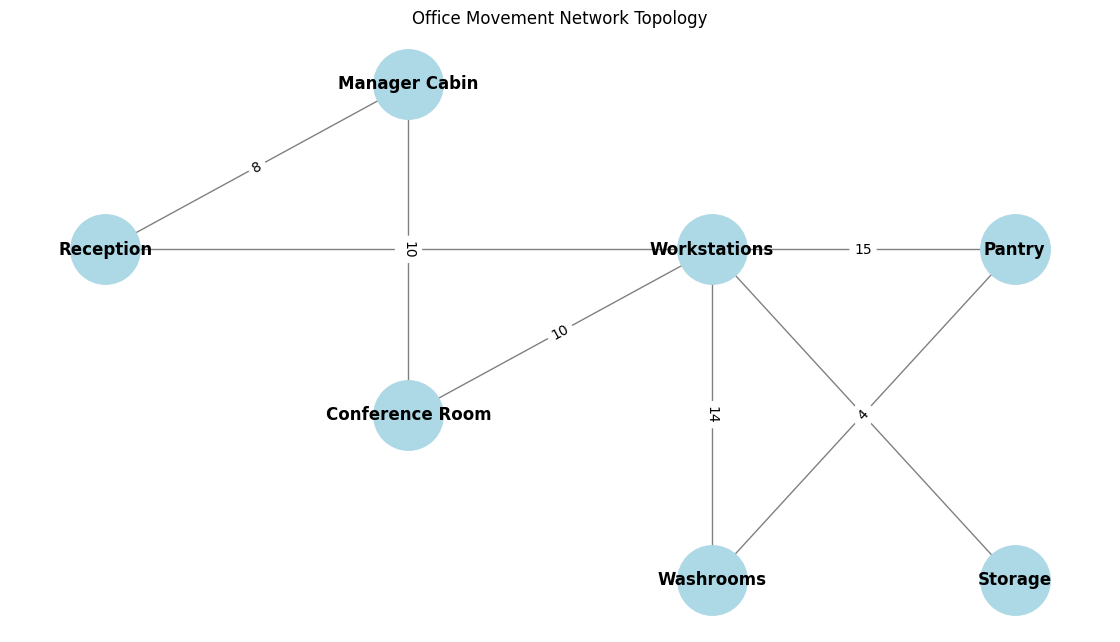

In [13]:
G = nx.Graph()
rooms_list = list(BASELINE_ROOMS.keys())
G.add_nodes_from(rooms_list)
G.add_weighted_edges_from(BASE_EDGES)

print("--- MODULE 9: GRAPH THEORY OUTPUT ---")
path_queries = [
    ("Reception", "Pantry"),
    ("Reception", "Storage"),
    ("Manager Cabin", "Washrooms"),
]

for source, target in path_queries:
    path = nx.shortest_path(G, source, target, weight="weight")
    distance = nx.shortest_path_length(G, source, target, weight="weight")
    print(f"{source} → {target}")
    print(f"  Shortest Path: {' → '.join(path)}")
    print(f"  Distance: {distance:.1f} ft")

centrality = nx.degree_centrality(G)
print("\nDegree Centrality (Traffic Hub Indicator):")
for room, value in centrality.items():
    print(f"  {room:18s}: {value:.2f}")

hub = max(centrality, key=centrality.get)
print(f"\nMost connected traffic hub: {hub}")

pos = {
    "Reception": (0, 2),
    "Manager Cabin": (2, 3),
    "Conference Room": (2, 1),
    "Workstations": (4, 2),
    "Pantry": (6, 2),
    "Storage": (6, 0),
    "Washrooms": (4, 0),
}

plt.figure(figsize=(11, 6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_weight="bold",
    edge_color="gray"
)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Office Movement Network Topology")
plt.axis("off")
plt.tight_layout()
plt.show()

## Module 10 — Multivariable Calculus: Balancing Space and Cost

Define a performance index:

[ P(S,C)=\frac{S}{C} ]

where (S) is space allocation and (C) is cost.

Partial derivatives show how performance changes when one variable changes while the other is held constant:

[ \frac{\partial P}{\partial S}=\frac{1}{C}, \qquad \frac{\partial P}{\partial C}=-\frac{S}{C^2} ]

A contour plot visualizes performance over a range of space and cost values.

--- MODULE 10: MULTIVARIABLE CALCULUS OUTPUT ---
Performance Model: P(S, C) = S/C_cost
Partial Derivative w.r.t. Space: dP/dS = 1/C_cost
Partial Derivative w.r.t. Cost:  dP/dC = -S/C_cost**2


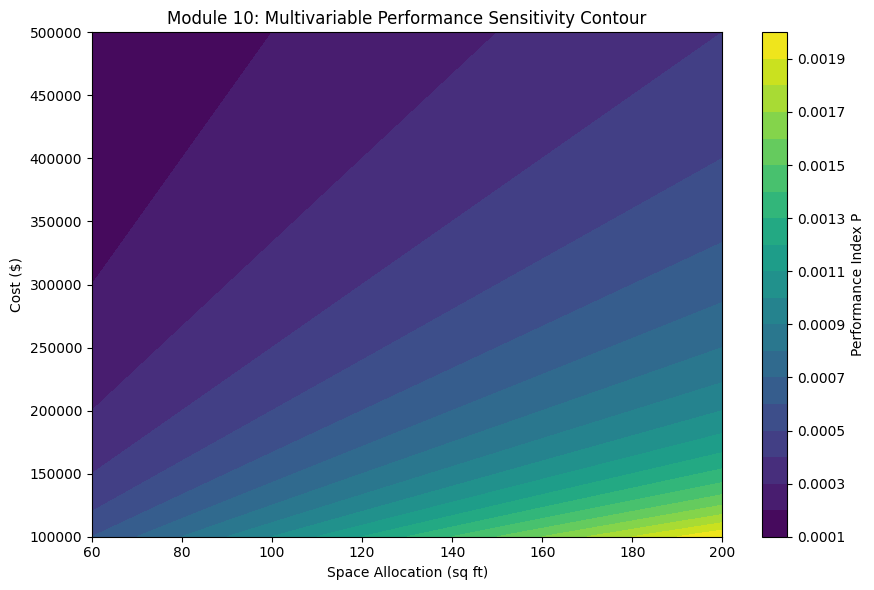

In [14]:
S, C_cost = sp.symbols("S C_cost", positive=True)
performance_expr = S / C_cost
partial_S = sp.diff(performance_expr, S)
partial_C = sp.diff(performance_expr, C_cost)

print("--- MODULE 10: MULTIVARIABLE CALCULUS OUTPUT ---")
print(f"Performance Model: P(S, C) = {performance_expr}")
print(f"Partial Derivative w.r.t. Space: dP/dS = {partial_S}")
print(f"Partial Derivative w.r.t. Cost:  dP/dC = {partial_C}")

space_values = np.linspace(60, 200, 150)
cost_values = np.linspace(100000, 500000, 150)
S_grid, C_grid = np.meshgrid(space_values, cost_values)
P_grid = S_grid / C_grid

plt.figure(figsize=(9, 6))
contour = plt.contourf(S_grid, C_grid, P_grid, levels=20)
plt.colorbar(contour, label="Performance Index P")
plt.xlabel("Space Allocation (sq ft)")
plt.ylabel("Cost ($)")
plt.title("Module 10: Multivariable Performance Sensitivity Contour")
plt.tight_layout()
plt.show()